CSV Files Found:
/kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv

Dataset Loaded Successfully!
Dataset Shape: (2518, 6)

Original Columns:
['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low']


,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23



Columns After Renaming:
['Date', 'Close', 'Volume', 'Open', 'High', 'Low']

Missing Values Before Final Cleaning:
Date      0
Close     0
Volume    0
Open      0
High      0
Low       0
dtype: int64

Dataset After Preprocessing:


,Date,Close,Volume,Open,High,Low,Next_Day_Close
0,2010-03-01,29.8557,137312041.0,29.3928,29.9286,29.3500,29.8357
1,2010-03-02,29.8357,141486282.0,29.9900,30.1186,29.6771,29.9043
2,2010-03-03,29.9043,92846488.0,29.8486,29.9814,29.7057,30.1014
3,2010-03-04,30.1014,89591907.0,29.8971,30.1314,29.8043,31.2786
4,2010-03-05,31.2786,224647427.0,30.7057,31.3857,30.6614,31.2971



Final Dataset Shape: (2517, 7)

Input Features:
['Open', 'High', 'Low', 'Close', 'Volume']

Target Column:
Next_Day_Close

Training Data Shape: (2013, 5)
Testing Data Shape: (504, 5)

Training Period:
2010-03-01 to 2018-02-26

Testing Period:
2018-02-27 to 2020-02-27

LINEAR REGRESSION MODEL RESULTS
Mean Absolute Error (MAE): 2.6353
Root Mean Squared Error (RMSE): 3.7141
R² Score: 0.992
R² Score Percentage: 99.2 %


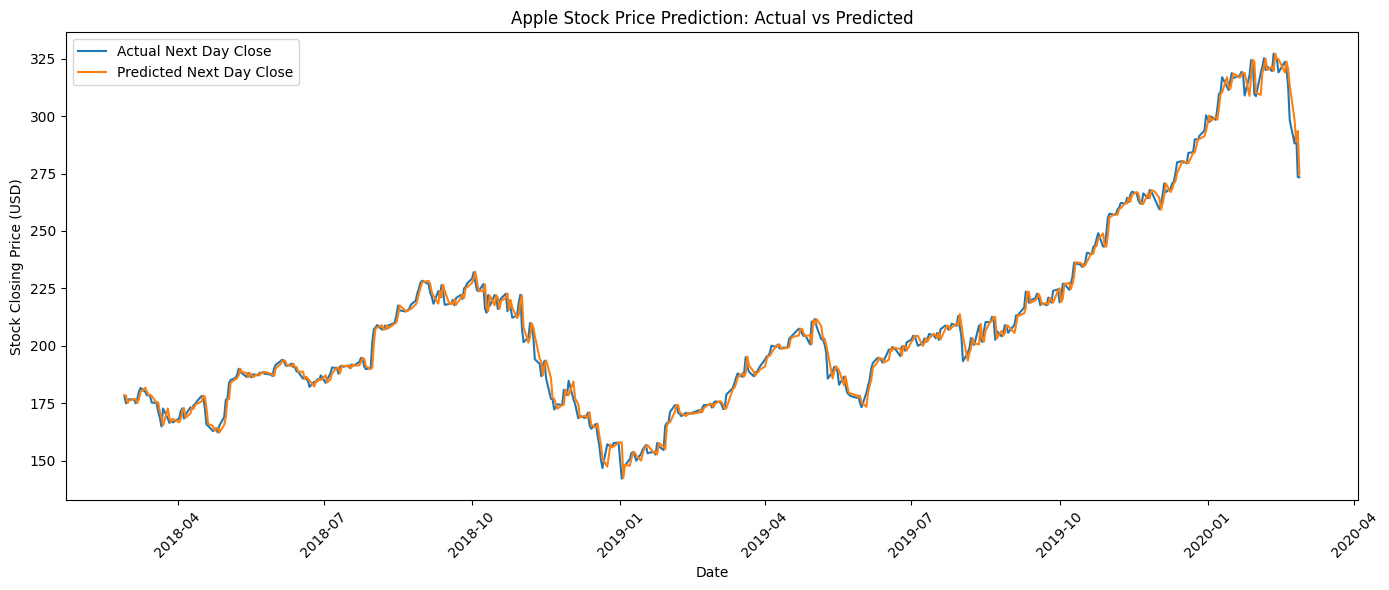


Prediction Results (First 10 Rows):


,Date,Actual_Next_Day_Close,Predicted_Next_Day_Close,Difference
0,2018-02-27,178.12,178.602346,0.482346
1,2018-02-28,175.00,178.366696,3.366696
2,2018-03-01,176.21,175.162926,1.047074
3,2018-03-02,176.82,176.231584,0.588416
4,2018-03-05,176.67,176.913038,0.243038
5,2018-03-06,175.03,176.719637,1.689637
6,2018-03-07,176.94,175.078570,1.861430
7,2018-03-08,179.98,176.934382,3.045618
8,2018-03-09,181.72,179.941854,1.778146
9,2018-03-12,179.97,181.817614,1.847614



Prediction file created successfully!
File name: apple_stock_price_predictions.csv


In [1]:
# ==========================================================
# TASK 2: APPLE STOCK PRICE PREDICTION
# Predicting Next Day Closing Price using Linear Regression
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------------
# STEP 1: LOAD DATASET
# ----------------------------------------------------------

# Automatically find the attached CSV file
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)

print("CSV Files Found:")
for file in csv_files:
    print(file)

file_path = csv_files[0]
df = pd.read_csv(file_path)

print("\nDataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

print("\nOriginal Columns:")
print(df.columns.tolist())

display(df.head())

# ----------------------------------------------------------
# STEP 2: CLEAN COLUMN NAMES
# ----------------------------------------------------------

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename column because this dataset commonly uses Close/Last
df.rename(columns={"Close/Last": "Close"}, inplace=True)

print("\nColumns After Renaming:")
print(df.columns.tolist())

# ----------------------------------------------------------
# STEP 3: DATA CLEANING AND PREPROCESSING
# ----------------------------------------------------------

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Convert price columns from text such as "$124.61" into numbers
price_columns = ["Close", "Open", "High", "Low"]

for col in price_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Convert Volume column into numeric form
df["Volume"] = (
    df["Volume"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Sort records from oldest date to latest date
df = df.sort_values(by="Date").reset_index(drop=True)

print("\nMissing Values Before Final Cleaning:")
print(df.isnull().sum())

# Remove any missing values if present
df.dropna(inplace=True)

# ----------------------------------------------------------
# STEP 4: CREATE TARGET COLUMN
# ----------------------------------------------------------

# Predict tomorrow's closing price
df["Next_Day_Close"] = df["Close"].shift(-1)

# Last record has no next day, so remove it
df.dropna(inplace=True)

print("\nDataset After Preprocessing:")
display(df.head())

print("\nFinal Dataset Shape:", df.shape)

# ----------------------------------------------------------
# STEP 5: SELECT FEATURES AND TARGET
# ----------------------------------------------------------

features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["Next_Day_Close"]

print("\nInput Features:")
print(features)

print("\nTarget Column:")
print("Next_Day_Close")

# ----------------------------------------------------------
# STEP 6: TIME-BASED TRAIN-TEST SPLIT
# ----------------------------------------------------------

# Use first 80% historical data for training
# Use latest 20% records for testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_dates = df["Date"].iloc[split_index:]

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Period:")
print(df["Date"].iloc[0].date(), "to", df["Date"].iloc[split_index - 1].date())

print("\nTesting Period:")
print(df["Date"].iloc[split_index].date(), "to", df["Date"].iloc[-1].date())

# ----------------------------------------------------------
# STEP 7: TRAIN LINEAR REGRESSION MODEL
# ----------------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# ----------------------------------------------------------
# STEP 8: EVALUATE MODEL
# ----------------------------------------------------------

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n" + "=" * 60)
print("LINEAR REGRESSION MODEL RESULTS")
print("=" * 60)
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))
print("R² Score Percentage:", round(r2 * 100, 2), "%")

# ----------------------------------------------------------
# STEP 9: ACTUAL VS PREDICTED GRAPH
# ----------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Next Day Close"
)

plt.plot(
    test_dates,
    predictions,
    label="Predicted Next Day Close"
)

plt.title("Apple Stock Price Prediction: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Stock Closing Price (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 10: SHOW PREDICTION RESULTS
# ----------------------------------------------------------

results = pd.DataFrame({
    "Date": test_dates.values,
    "Actual_Next_Day_Close": y_test.values,
    "Predicted_Next_Day_Close": predictions,
    "Difference": abs(y_test.values - predictions)
})

print("\nPrediction Results (First 10 Rows):")
display(results.head(10))

# ----------------------------------------------------------
# STEP 11: SAVE PREDICTIONS FILE
# ----------------------------------------------------------

results.to_csv(
    "/kaggle/working/apple_stock_price_predictions.csv",
    index=False
)

print("\nPrediction file created successfully!")
print("File name: apple_stock_price_predictions.csv")